# **Modeling: Dự đoán `quantity_sold`**

Notebook này xây dựng và đánh giá 3 mô hình:
- Linear Regression
- Random Forest Regressor
- XGBoost Regressor

Mỗi mô hình tạo ra:
- Feature importance (Top 10)
- File dự đoán CSV phục vụ so sánh mô hình


## **1. Thiết lập môi trường**

Import các hàm từ file `models.py`

In [1]:
import sys
import os

# thêm thư mục src vào python path
sys.path.append(os.path.abspath("../src"))

from models import (
    train_linear_regression_elasticnet,
    train_random_forest_regressor,
    train_xgboost_regressor,
    run_model_comparison
)

## **2. Kiểm tra dữ liệu**

Kiểm tra vài dòng đầu của dữ liệu.


In [2]:
import pandas as pd

train_df = pd.read_csv("../data/processed/train_data_final.csv")
test_df  = pd.read_csv("../data/processed/test_data_final.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (15848, 55)
Test shape: (3963, 55)


,price,original_price,discount_rate,quantity_sold,rating_average,review_count,is_return_policy,is_freeship_xtra,is_authentic,image_count,...,category_root_name_Điện Thoại - Máy Tính Bảng,category_root_name_Điện Tử - Điện Lạnh,category_root_name_Đồ chơi - Mẹ & Bé,China,Japan,South Korea,Thailand,USA,Vietnam,Others
0,0.445108,0.438575,0.000000,3.828641,0.74,0.331717,1.0,1.0,1.0,0.411765,...,0,0,0,1,1,0,0,0,0,0.00
1,0.313109,0.343930,0.500000,3.828641,1.00,0.367314,1.0,0.0,0.0,0.000000,...,0,0,0,0,0,0,0,0,0,0.25
2,0.156620,0.148556,0.000000,0.000000,0.00,0.000000,0.0,1.0,1.0,0.176471,...,0,0,0,0,0,0,0,0,1,0.00
3,0.263237,0.330742,0.846154,3.218876,0.86,0.310416,1.0,1.0,1.0,0.294118,...,0,0,0,0,0,0,0,0,0,0.25
4,0.396891,0.390102,0.000000,1.945910,0.80,0.175253,1.0,1.0,1.0,0.235294,...,0,0,0,1,0,0,1,0,0,0.00


## **3. Linear Regression**

**Pipeline:**
1. Load train/test
2. Drop leak feature `review_to_sold_ratio`
3. ElasticNetCV tìm `alpha`, `l1_ratio`
4. Train lần 1 -> chọn feature theo `|coef| > threshold`
5. Train final model trên tập feature đã chọn
6. Vẽ Top 10 coef (abs) và lưu ảnh``
7. Predict test và lưu `lr_predictions.csv`


Best alpha: 0.0001
Best l1_ratio: 0.4
Total selected features: 50
[FINAL MODEL] Number of selected features: 50


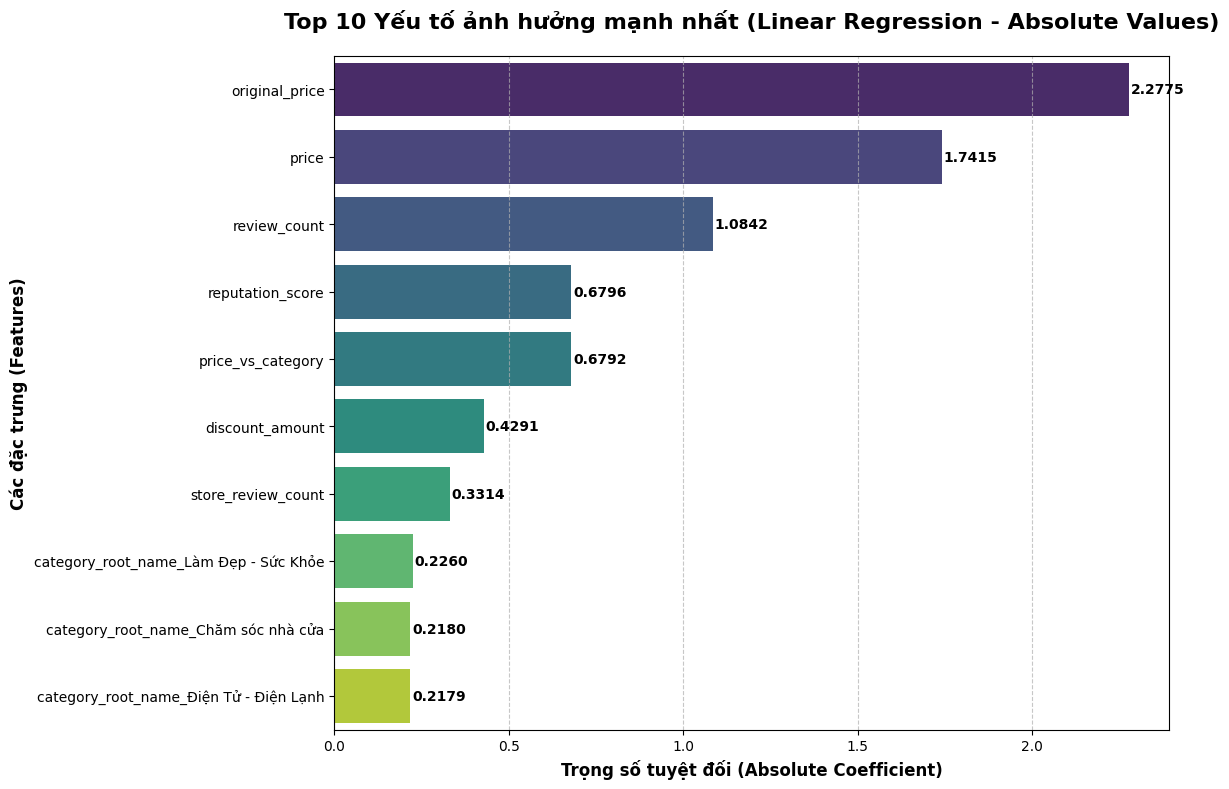


Test Set Performance:
MAE: 0.5884
MSE: 0.6682
RMSE: 0.8174
R2: 0.8723
LR metrics: {'MAE': 0.5884152225833924, 'MSE': 0.6682207237600719, 'RMSE': np.float64(0.8174476886994494), 'R2': 0.8722908239934661}


,feature,coefficient,abs_coefficient
0,original_price,2.277516,2.277516
1,price,-1.741496,1.741496
2,review_count,1.084154,1.084154
3,reputation_score,0.679598,0.679598
4,price_vs_category,-0.679180,0.679180
5,discount_amount,-0.429085,0.429085
6,store_review_count,0.331391,0.331391
7,category_root_name_Làm Đẹp - Sức Khỏe,0.226006,0.226006
8,category_root_name_Chăm sóc nhà cửa,0.218039,0.218039
9,category_root_name_Điện Tử - Điện Lạnh,-0.217934,0.217934


In [3]:
lr_result = train_linear_regression_elasticnet()

print("LR metrics:", lr_result["metrics"])
lr_result["coef_df"].head(10)

## **4. Random Forest Regressor**

**Pipeline:**
1. Load train/test
2. GridSearchCV tìm best params (scoring = R²)
3. Train best estimator → predict test
4. Tính R² và RMSE
5. Vẽ Top 10 feature importance và lưu ảnh
6. Lưu `rfr_predictions.csv`


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best RF params:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
RF R2 (test): 0.9299
RF RMSE (test): 0.6056
Random Forest Feature Importances:
review_count                                           0.241831
reputation_score                                       0.221212
review_to_sold_ratio                                   0.133940
rating_average                                         0.105955
store_review_count                                     0.049148
shop_potential                                         0.041499
total_follower                                         0.037775
price                                                  0.021150
original_price                                         0.019747
price_vs_category                                      0.016500
name_length                                            0.009268
trust_level                

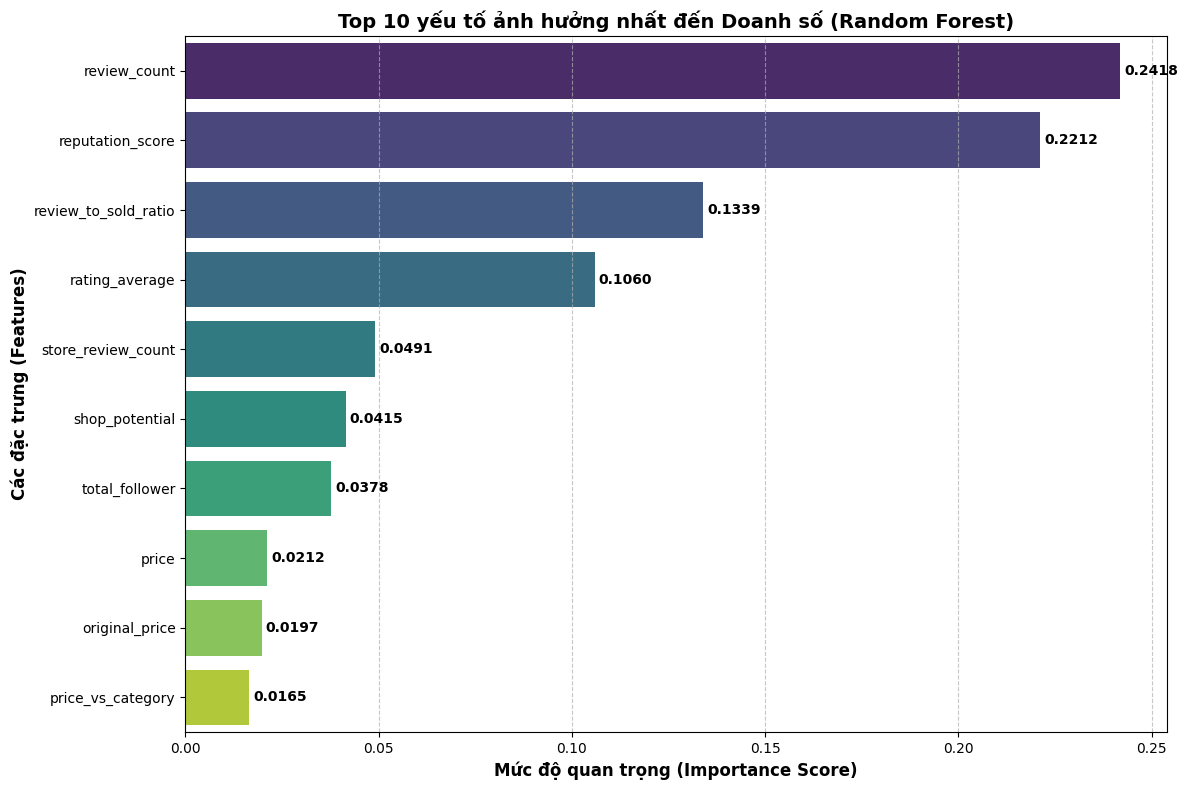

RF metrics: {'R2': 0.929918040604323, 'RMSE': np.float64(0.6055528279332725)}


review_count            0.241831
reputation_score        0.221212
review_to_sold_ratio    0.133940
rating_average          0.105955
store_review_count      0.049148
shop_potential          0.041499
total_follower          0.037775
price                   0.021150
original_price          0.019747
price_vs_category       0.016500
dtype: float64

In [4]:
rf_result = train_random_forest_regressor()

print("RF metrics:", rf_result["metrics"])
rf_result["feature_importances"].head(10)

## **5. XGBoost Regressor**

**Pipeline:**
1. Split train thành train/val = 80/20
2. Train baseline để lấy feature importance ban đầu (early stopping)
3. Loại các cột gây nhiễu trước khi tune/train (`cols_to_drop`)
4. RandomizedSearchCV tìm hyperparameters tốt
5. Train final model trên toàn bộ dữ liệu (train + val)
6. Predict test
7. Đánh giá trên thang gốc bằng `expm1` (RMSE/MAE/R²)
8. Vẽ Top N feature importance và lưu ảnh
9. Lưu `xgbr_predictions.csv`

Feature Importances:
review_count                                           0.537490
reputation_score                                       0.077109
rating_average                                         0.047562
review_to_sold_ratio                                   0.042582
category_root_name_Nhà Cửa - Đời Sống                  0.034748
category_root_name_Nhà Sách Tiki                       0.032886
category_root_name_Làm Đẹp - Sức Khỏe                  0.030324
category_root_name_Thời trang nữ                       0.015663
is_return_policy                                       0.015544
category_root_name_Túi thời trang nữ                   0.013838
is_freeship_xtra                                       0.009357
South Korea                                            0.009285
category_root_name_Đồ chơi - Mẹ & Bé                   0.008930
store_review_count                                     0.008871
total_follower                                         0.008741
original_price     

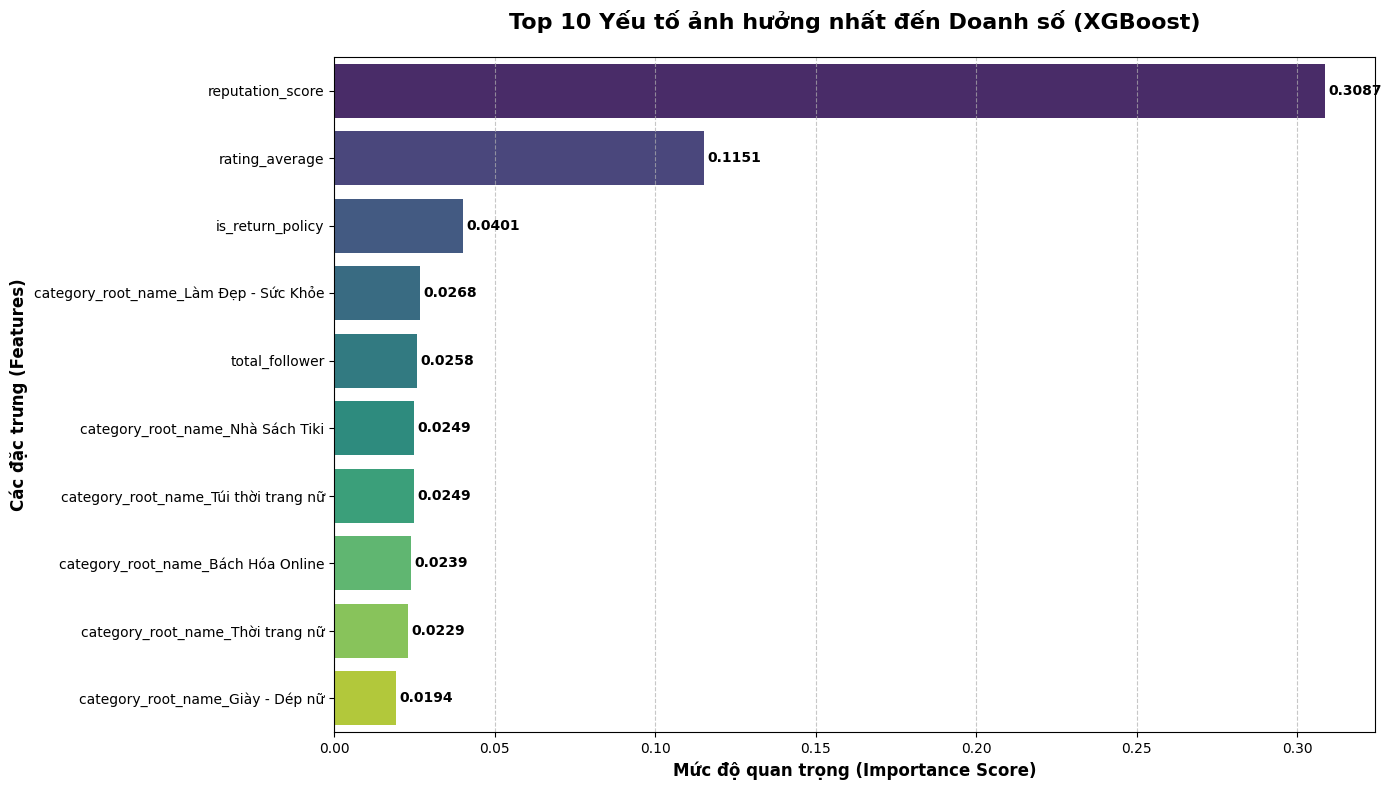

XGB metrics: {'RMSE': np.float64(672.7865902232621), 'MAE': 120.0255995439722, 'R2': 0.6272528401730741}


reputation_score                         0.308670
rating_average                           0.115117
is_return_policy                         0.040148
category_root_name_Làm Đẹp - Sức Khỏe    0.026767
total_follower                           0.025826
category_root_name_Nhà Sách Tiki         0.024932
category_root_name_Túi thời trang nữ     0.024903
category_root_name_Bách Hóa Online       0.023942
category_root_name_Thời trang nữ         0.022926
category_root_name_Giày - Dép nữ         0.019359
dtype: float32

In [5]:
xgb_result = train_xgboost_regressor()

print("XGB metrics:", xgb_result["metrics_real"])
xgb_result["feature_importances_final"].head(10)

## **6. So sánh mô hình**

Dùng các file prediction CSV để:
- Tính metric trên log-scale và real-scale
- Vẽ biểu đồ so sánh + scatter predicted vs actual
- Lưu ảnh vào `../data/images/`


                     Model      RMSE       MAE        R²   RMSE Real  \
0        XGBoost Regressor  0.709306  0.501531  0.903845  672.786609   
1  Random Forest Regressor  0.605553  0.413423  0.929918  663.522456   
2        Linear Regression  0.817448  0.588415  0.872291  752.405823   

     MAE Real   R² Real  
0  120.025604  0.627253  
1  111.497897  0.637447  
2  137.874148  0.533809  
Đã tạo xong file comparison & predicted_vs_actual!


,Model,RMSE,MAE,R²,RMSE Real,MAE Real,R² Real
0,XGBoost Regressor,0.709306,0.501531,0.903845,672.786609,120.025604,0.627253
1,Random Forest Regressor,0.605553,0.413423,0.929918,663.522456,111.497897,0.637447
2,Linear Regression,0.817448,0.588415,0.872291,752.405823,137.874148,0.533809


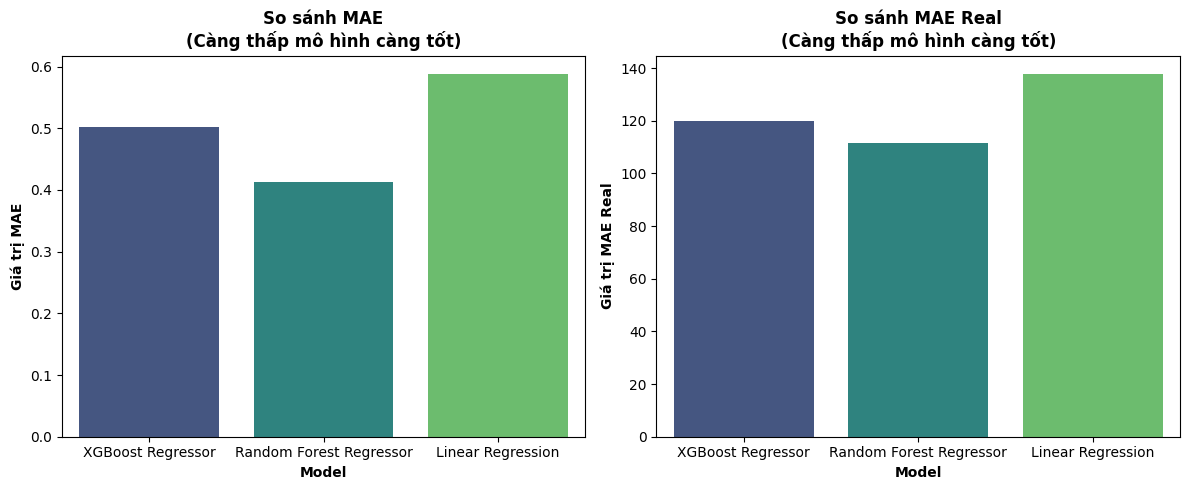

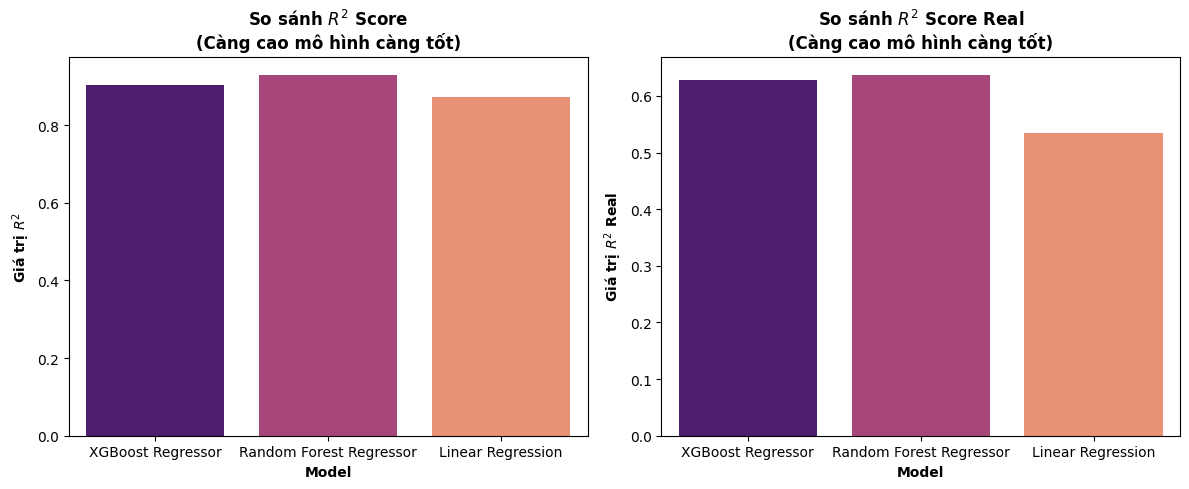

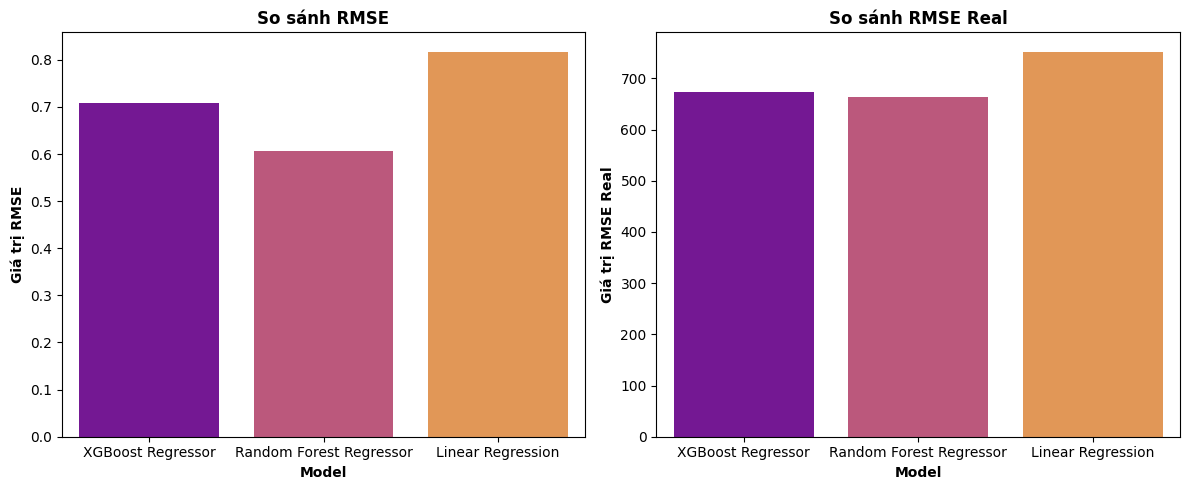

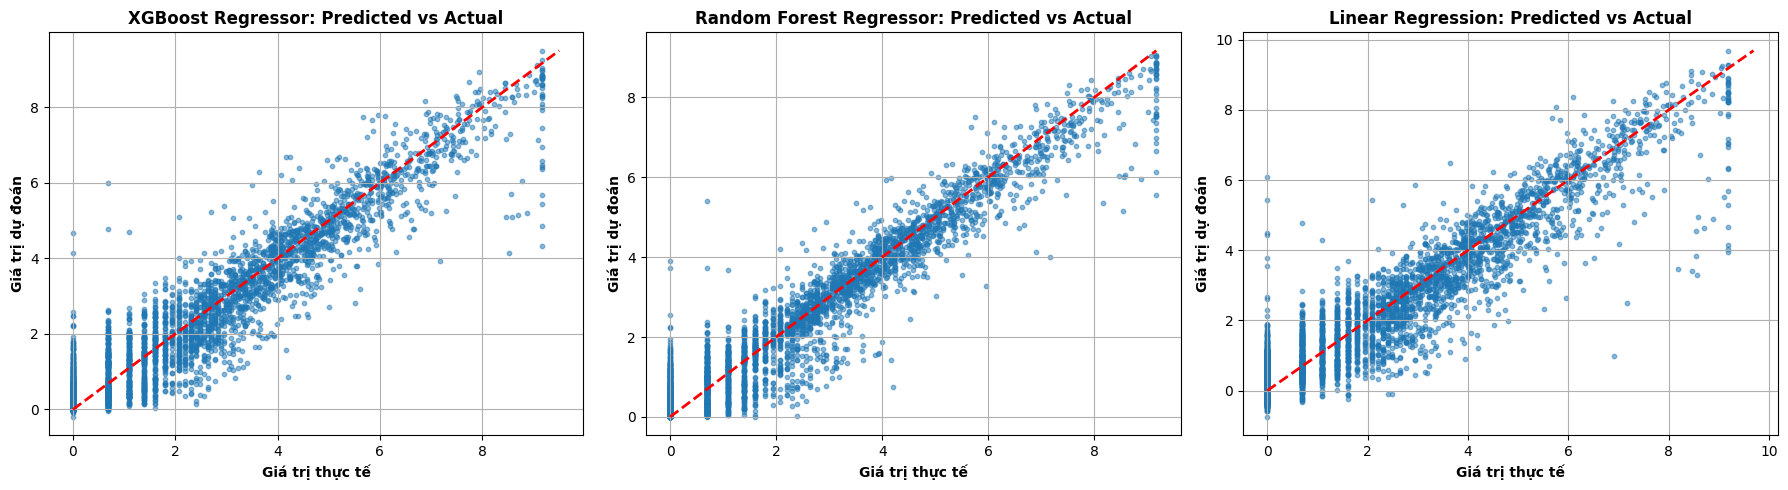

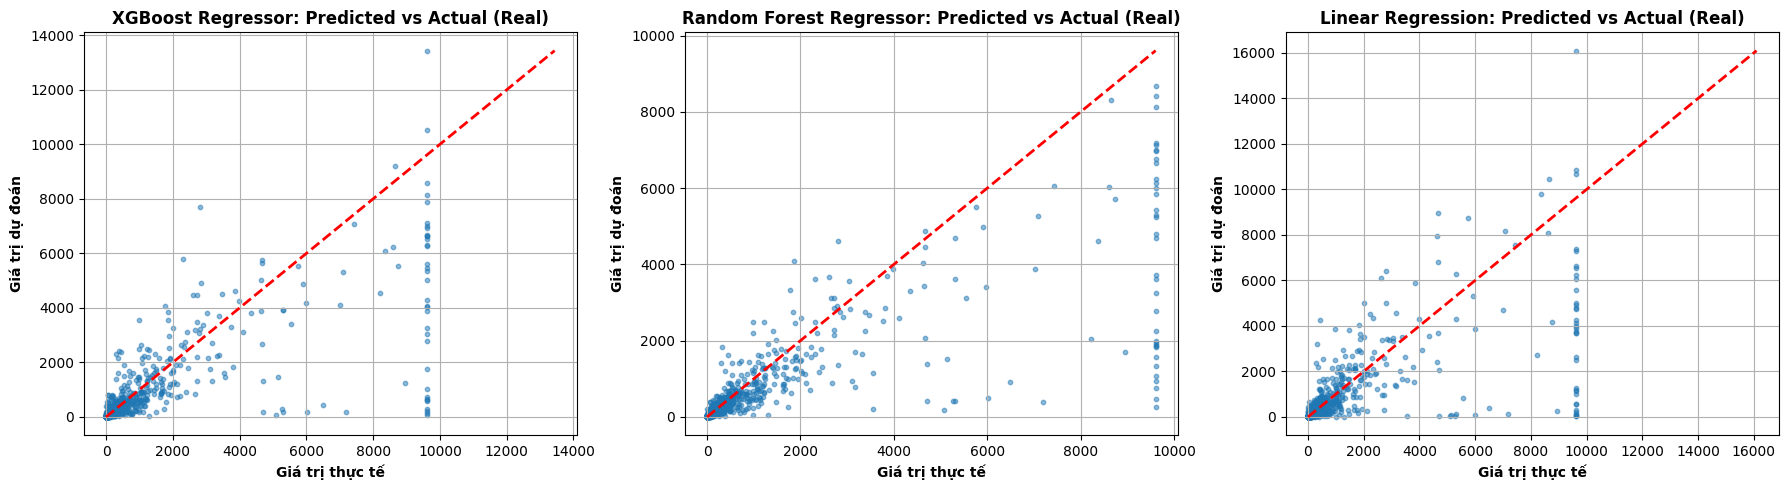

In [6]:
comparison_df = run_model_comparison()
comparison_df

<center>

# **PHÂN TÍCH KẾT QUẢ THỐNG KÊ**

| Model | RMSE | MAE | $R^2$ | RMSE Real | MAE Real | $R^2$ Real |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Linear Regression** | 0.817448 | 0.588415 | 0.872291 | 752.405823 | 137.874148 | 0.533809 |
| **Random Forest Regressor** | 0.605553 | 0.413423 | 0.929918 | 663.522456 | 111.497897 | 0.637447 |
| **XGBoost Regressor** | 0.709306 | 0.501531 | 0.903845 | 672.786609 | 120.025604 | 0.627253 |

</center>

- **Mô hình tốt nhất**: Dựa trên bảng thống kê, Random Forest Regressor là mô hình hiệu quả nhất trên mọi chỉ số. Cụ thể, mô hình đạt $R^2 \approx 0.93$ (giải thích được 93% sự biến thiên của dữ liệu trên thang đo log) và có sai số thấp nhất $MAE \approx 0.41$.

    - Chỉ số MAE Real của Random Forest là 111.5. Điều này có ý nghĩa thực tế rất quan trọng, trung bình mỗi dự đoán doanh số bán ra sẽ sai lệch khoảng 111-112 đơn vị sản phẩm so với thực tế.

    - RMSE Real (663.52) cao hơn đáng kể so với MAE, cho thấy dữ liệu vẫn còn một số điểm dữ liệu outliers hoặc các mặt hàng có doanh số cực cao mà mô hình chưa dự đoán hoàn toàn chính xác.

    - Có thể thấy $R^2$ trên thang Log rất cao (0.93) nhưng khi chuyển về thang Real thì giảm xuống (0.64).

    - Điều này cho thấy việc thực hiện Log Transformation đã giúp mô hình học được rất tốt các dữ liệu bị lệch.

- Linear Regression cho kết quả thấp nhất, chứng tỏ mối quan hệ giữa các đặc trưng và số lượng bán ra mang tính phi tuyến phức tạp, các mô hình dựa trên cây (Tree-based) như Random Forest và XGBoost xử lý tốt hơn.

- XGBoost có các chỉ số bám sát Random Forest nhưng trong bài toán này lại không vượt trội hơn, có thể do cấu hình tham số hiện tại của Random Forest phù hợp hơn với tập dữ liệu sau khi đã Winsorizing.

- Với mục tiêu dự đoán doanh số để lập kế hoạch nhập hàng, sai số $R^2 \approx 111$ đơn vị trên mỗi mặt hàng là con số có thể chấp nhận được, giúp giảm thiểu rủi ro tồn kho đáng kể so với việc dự đoán cảm tính.

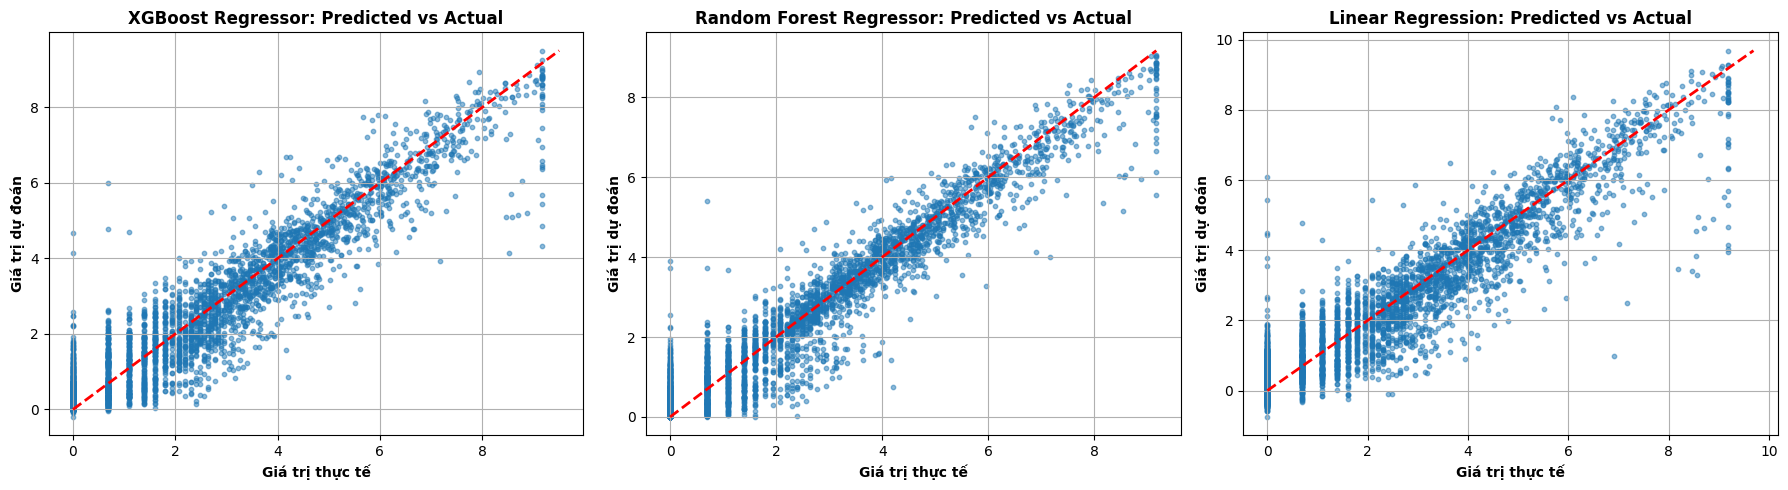

- Biểu đồ này thể hiện mối quan hệ giữa giá trị dự đoán và giá trị thực tế sau khi đã thực hiện biến đổi Log Transformation và khử nhiễu (Winsorizing).

- Các điểm dữ liệu tập trung rất sát và chạy dọc theo đường chéo 45 độ (đường dự đoán hoàn hảo). Điều này cho thấy mô hình có độ khớp cực kỳ tốt với dữ liệu đã được chuẩn hóa.

- Việc các điểm phân bố đều từ thấp đến cao trên trục Log chứng minh mô hình đã nắm bắt được quy luật tăng trưởng của doanh số. Nó không bị lệch về phía dự đoán quá cao hay quá thấp. Chỉ số $R^2$ ở thang đo này khẳng định thuật toán (đặc biệt là Random Forest) đã học được tới 93% đặc tính của dữ liệu.

- Chứng minh các bước tiền xử lý (Preprocessing) đã phát huy tác dụng, biến dữ liệu từ dạng lệch về dạng phân phối chuẩn hơn, giúp mô hình dễ học hơn.

- Nhận xét:

    - Random Forest Regressor

        - Các điểm dữ liệu tập trung sát đường y = x nhất, thể hiện khả năng dự đoán ổn định.

        - Phân tán nhỏ hơn so với các mô hình còn lại trên toàn miền giá trị.

    -> Là mô hình tốt nhất.

    - XGBoost Regressor

        - Dự đoán bám theo xu hướng chung tốt, đặc biệt ở vùng giá trị trung bình và lớn.

        - Tuy nhiên xuất hiện một số điểm lệch xa đường chéo hơn so với Random Forest.

    -> Hiệu năng tốt nhưng kém hơn Random Forest về độ ổn định.

    - Linear Regression

        - Chỉ bắt được xu hướng tuyến tính tổng quát.

        - Sai lệch rõ rệt ở các vùng biên, đặc biệt khi dữ liệu có tính phi tuyến.

    -> Kém nhất.

**=> Random Forest > XGBoost > Linear Regression**

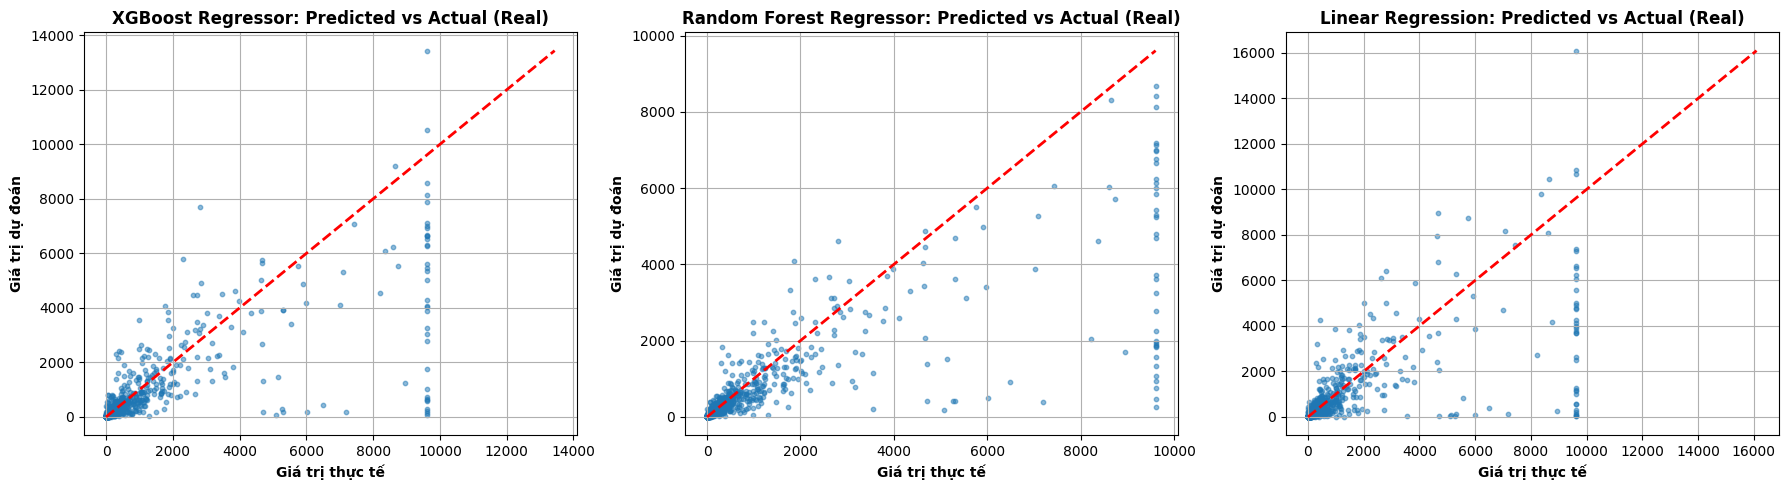

- Biểu đồ này thể hiện kết quả dự báo đưa về đơn vị thực tế

- Ở các vùng giá trị nhỏ (doanh số thấp), các điểm vẫn bám khá sát đường thẳng. Tuy nhiên, khi giá trị thực tế tăng lên (vùng bên phải trục hoành), các điểm dữ liệu bắt đầu "xòe" ra và nằm xa đường chéo hơn. Đây chính là sự ảnh hưởng của các điểm outliers. Trong thương mại điện tử, có những mặt hàng đột biến doanh số (do flash sale, xu hướng, khuyến mãi, ...) mà các biến đầu vào hiện tại chưa giải thích hết được.

- Mặc dù ở thang đo này $R^2$ giảm xuống, nhưng nhìn chung mô hình vẫn đi đúng hướng (vẫn có xu hướng tăng dần theo đường chéo), không bị tình trạng dự đoán hỗn loạn.

- Biểu đồ này phản ánh đúng thực tế kinh doanh, dự đoán các mặt hàng bán đều đặn thì rất dễ, nhưng dự đoán chính xác các mặt hàng hot là một thách thức lớn.

- Nhận xét:

    - Random Forest Regressor

        - Các điểm dự đoán vẫn bám sát đường chéo hơn so với các mô hình khác.

        - Mô hình có xu hướng nén dự đoán ở vùng giá trị lớn nhưng giúp hạn chế sai số cực đoan.

    -> Là mô hình tốt nhất.

    - XGBoost Regressor

        - Dự đoán linh hoạt hơn ở một số giá trị lớn.

        - Thể hiện khả năng chịu outlier tốt hơn các mô hình còn lại.

    -> Đứng thứ hai.

    - Linear Regression

        - Phân tán rất mạnh, nhiều điểm cách xa đường y = x.

        - Chịu ảnh hưởng lớn bởi outliers và không phù hợp với dữ liệu gốc.

    -> Kém nhất.

**=> Random Forest > XGBoost >>> Linear Regression**

**Kết luận chung**

- Trong khi biểu đồ Log (Winsorizing + Log) khẳng định sức mạnh toán học và khả năng học quy luật của mô hình, thì biểu đồ Real (Winsorizing) giúp ta nhìn nhận khách quan về những sai số không thể tránh khỏi khi đối mặt với dữ liệu thực tế đầy biến động. 

- Việc Random Forest giữ được đường đi sát đường phân giác nhất trong cả 2 biểu đồ đã chứng minh đây là mô hình tối ưu để lập kế hoạch nhập hàng.

<center>

**Feature Importance**

</center>

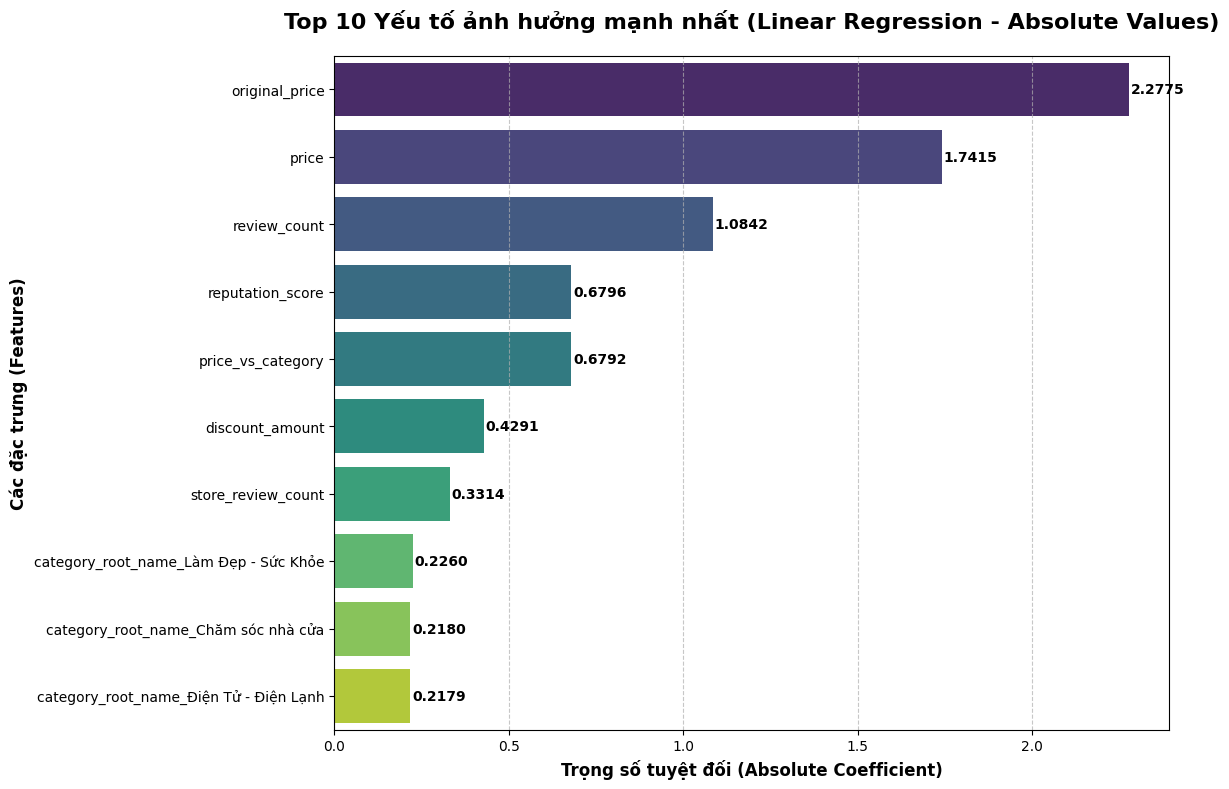

- Doanh số chịu ảnh hưởng mạnh theo quan hệ tuyến tính bởi:

    - Giá gốc (`original_price`)

    - Giá bán (`price`)

- Các yếu tố về bằng chứng xã hội (`review_count`, `reputation_score`) vẫn giữ vai trò quan trọng nhưng mức độ ảnh hưởng thấp hơn so với yếu tố giá trong mô hình tuyến tính.

- Cho thấy Linear Regression nhấn mạnh các yếu tố có tác động trực tiếp, ổn định và tuyến tính đến doanh số.

- Tuy nhiên, mô hình không nắm bắt được các hiệu ứng phi tuyến như ngưỡng tâm lý, sự tương tác giữa review – rating – uy tín, hay hiện tượng bão hòa.

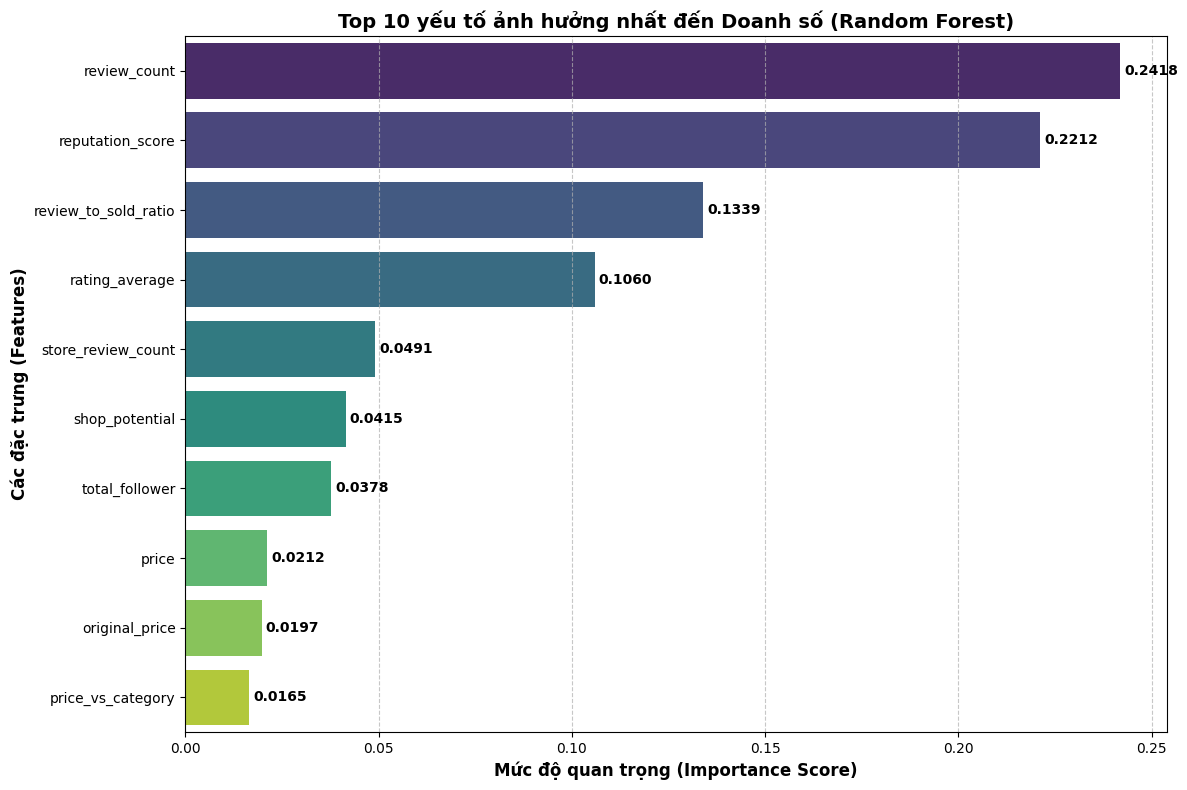

- Doanh số (`quantity_sold`) bị chi phối mạnh bởi bằng chứng xã hội:

    - Số lượng review (`review_count`)

    - Uy tín gian hàng (`reputation_score`)

    - Tỷ lệ review trên số bán (`review_to_sold_ratio`)

- Các yếu tố liên quan đến đánh giá người dùng (`rating_average`) tiếp tục đóng vai trò quan trọng trong việc thúc đẩy quyết định mua.

- Giá (`price`, `original_price`) có mức độ quan trọng thấp hơn, cho thấy mô hình nhận diện rằng niềm tin và trải nghiệm người dùng quan trọng hơn giá rẻ.

- Random Forest phản ánh hành vi mua thực tế trên sàn Tiki là người tiêu dùng ưu tiên sản phẩm đến từ gian hàng đáng tin cậy hơn là chỉ dựa vào mức giá thấp.

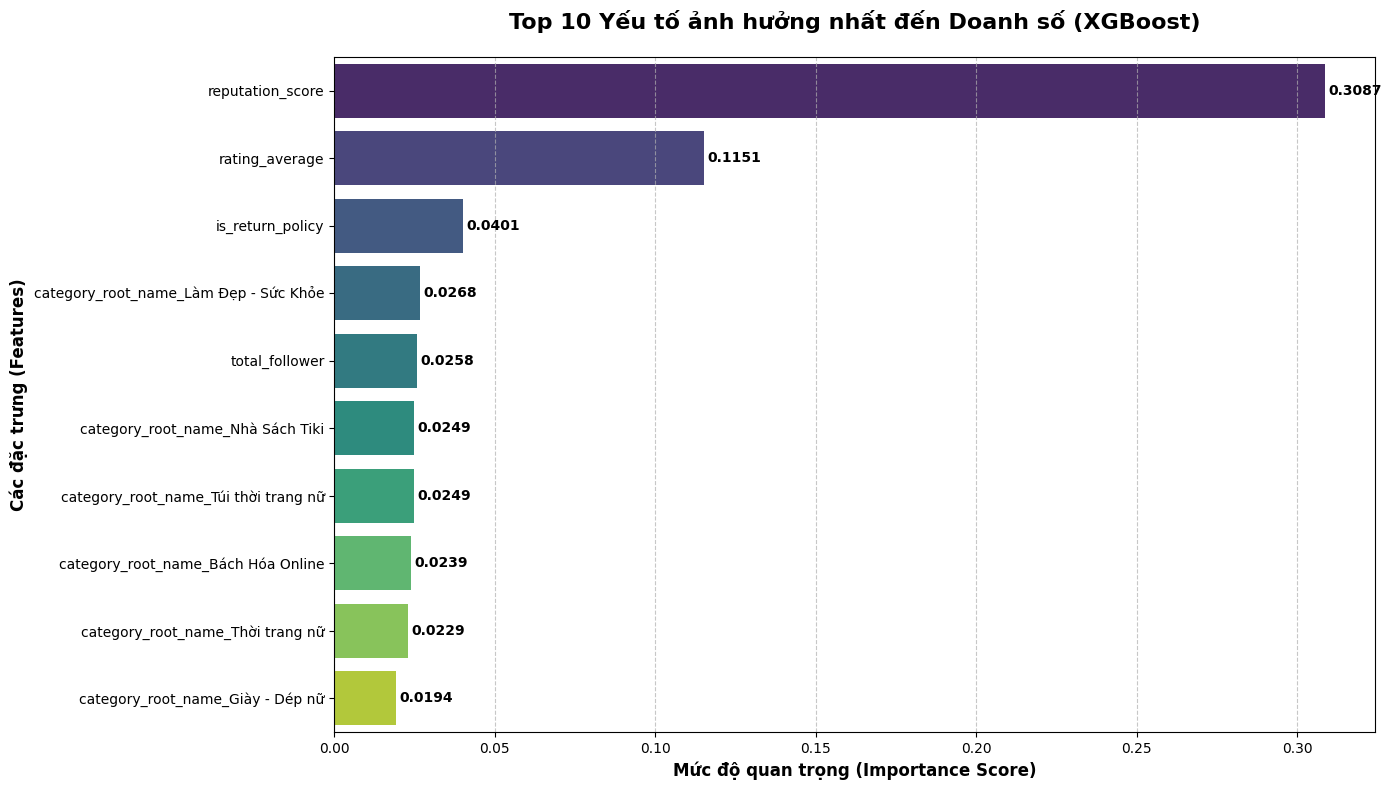

- Doanh số bị chi phối mạnh nhất bởi uy tín gian hàng (`reputation_score`), thể hiện rõ vai trò trung tâm của yếu tố niềm tin.

- Chất lượng cảm nhận của sản phẩm (`rating_average`) tiếp tục là yếu tố quan trọng, củng cố quyết định mua.

- Chính sách đổi trả (`is_return_policy`) có ảnh hưởng đáng kể, cho thấy người mua quan tâm đến mức độ an toàn khi giao dịch.

- Các biến ngành hàng (`category_root_name_*`) xuất hiện trong top quan trọng, cho thấy doanh số không chỉ phụ thuộc vào sản phẩm hay gian hàng mà còn chịu ảnh hưởng bởi đặc thù nhu cầu của từng ngành

- XGBoost phản ánh bối cảnh kinh doanh tổng thể, nơi uy tín, chính sách và ngành hàng cùng tương tác để tác động đến doanh số.

**Kết luận tổng quát**

- Các mô hình phi tuyến (Random Forest, XGBoost) cho thấy niềm tin và bằng chứng xã hội là yếu tố quyết định doanh số trên sàn thương mại điện tử.

- Linear Regression thiên về đánh giá tác động tuyến tính của giá, phù hợp cho việc diễn giải xu hướng nhưng hạn chế trong việc mô tả hành vi mua thực tế.

- Sự khác biệt giữa các mô hình khẳng định rằng mối quan hệ giữa các yếu tố và doanh số là phi tuyến, và cần sử dụng mô hình cây để phản ánh đúng thực tế thị trường.